# Projeto 1 — Demand Drivers & Commercial Forecast

## Electronics e Personal Care

### Objetivo
Investigar se variáveis comerciais ajudam a explicar a demanda e construir um modelo de previsão condicionado a fatores como:

- preço;
- desconto;
- promoção;
- estoque;
- categoria;
- calendário.

Nesta fase, restringimos a análise a **Electronics** e **Personal Care**, categorias nas quais o forecast univariado apresentou uma dinâmica futura visualmente mais coerente com a oscilação histórica.

> **Importante:** associação não significa causalidade. O objetivo é avaliar capacidade explicativa e preditiva, não provar que uma variável comercial causou a variação de vendas.


## Por que existe esta versão corrigida?

Esta versão surgiu como resultado direto do próprio processo de análise.

Na etapa anterior de forecasting, os gráficos de **Electronics** e **Personal Care** apresentaram oscilações semanais relevantes e um comportamento futuro que justificava uma investigação mais detalhada. Em vez de assumir imediatamente que essas variações eram explicadas por fatores como promoção, desconto, preço ou estoque, foi criado um notebook específico para investigar os números e testar essa hipótese.

A investigação mostrou que uma parte importante da volatilidade dos totais semanais estava associada à **quantidade de registros disponíveis em cada semana**. Em outras palavras, semanas com mais observações tendiam naturalmente a apresentar maiores volumes agregados de `units_sold`, o que poderia levar a uma interpretação incorreta dos picos e vales como mudanças reais de demanda.

Além disso, o primeiro cenário futuro havia criado combinações de **loja × dia** em uma densidade muito superior à observada historicamente. Ao somar essas previsões, o resultado ficou artificialmente inflado em relação à escala original da base.

Por esse motivo, esta versão foi construída para incorporar o resultado dessa investigação e corrigir a metodologia de projeção. O forecast futuro passa a preservar uma **densidade de observações semelhante à histórica**, permitindo comparar cenários comerciais em uma escala mais coerente com os dados disponíveis.

Portanto, esta versão representa uma evolução do projeto baseada em:

1. observação dos resultados iniciais;
2. formulação de uma hipótese sobre a volatilidade;
3. investigação dos números em um notebook complementar;
4. identificação de uma limitação metodológica;
5. revisão do modelo de projeção.

> Esse processo é parte importante do projeto: o objetivo não foi apenas produzir uma previsão, mas **questionar o resultado, testar sua consistência e revisar a abordagem quando os dados indicaram essa necessidade**.


## 1. Bibliotecas e leitura da base tratada


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

ARQUIVO = "retail_sales_cleaned_project1.csv"

df = pd.read_csv(
    ARQUIVO,
    parse_dates=["date"]
)

categorias = ["Electronics", "Personal Care"]

base = (
    df[df["category"].isin(categorias)]
    .copy()
    .sort_values("date")
    .reset_index(drop=True)
)

print(f"Linhas selecionadas: {len(base):,}")
print(f"Período: {base['date'].min().date()} a {base['date'].max().date()}")
display(base.head())


Linhas selecionadas: 1,097
Período: 2024-01-01 a 2024-12-31


,store_id,product_id,date,category,price,promotion_active,discount_percent,units_sold,inventory_level,day_of_week,day_of_week_original,weekday_was_correct,year,month,month_name,quarter,week,is_weekend,gross_revenue,effective_price_est,net_sales_est
0,49,1341,2024-01-01,Personal Care,389,Yes,10,14,373,Monday,Thursday,False,2024,1,January,1,1,False,5446,350.10,"4,901.40"
1,39,1950,2024-01-02,Electronics,996,Yes,0,40,129,Tuesday,Saturday,False,2024,1,January,1,1,False,39840,996.00,"39,840.00"
2,36,1206,2024-01-02,Electronics,547,Yes,5,24,348,Tuesday,Sunday,False,2024,1,January,1,1,False,13128,519.65,"12,471.60"
3,24,1886,2024-01-02,Personal Care,1386,Yes,5,10,429,Tuesday,Wednesday,False,2024,1,January,1,1,False,13860,"1,316.70","13,167.00"
4,43,1080,2024-01-03,Electronics,671,Yes,0,34,477,Wednesday,Sunday,False,2024,1,January,1,1,False,22814,671.00,"22,814.00"


## 2. Diagnóstico da volatilidade semanal

Antes de relacionar picos de vendas com promoção, preço ou desconto, precisamos verificar se o total semanal pode estar sendo influenciado pela própria quantidade de observações existentes em cada semana.

Se uma semana possui mais linhas na base, naturalmente pode apresentar mais unidades vendidas quando usamos `sum(units_sold)`.

Por isso, calculamos:

- unidades totais;
- quantidade de registros;
- unidades médias por observação;
- preço médio;
- desconto médio;
- participação de promoções;
- estoque médio.


In [2]:
weekly_diag = (
    base.set_index("date")
        .groupby("category")
        .resample("W-SUN")
        .agg(
            units_sold=("units_sold", "sum"),
            records=("units_sold", "size"),
            avg_units_per_record=("units_sold", "mean"),
            avg_price=("price", "mean"),
            avg_discount=("discount_percent", "mean"),
            avg_inventory=("inventory_level", "mean"),
            promotion_rate=(
                "promotion_active",
                lambda x: (x == "Yes").mean() * 100
            )
        )
        .reset_index()
)

display(weekly_diag.head())


,category,date,units_sold,records,avg_units_per_record,avg_price,avg_discount,avg_inventory,promotion_rate
0,Electronics,2024-01-07,160,6,26.67,"1,054.33",0.83,259.33,66.67
1,Electronics,2024-01-14,234,11,21.27,"1,397.09",5.45,240.27,45.45
2,Electronics,2024-01-21,357,14,25.50,"1,475.64",3.57,203.71,28.57
3,Electronics,2024-01-28,283,12,23.58,"1,116.42",11.67,315.50,66.67
4,Electronics,2024-02-04,218,9,24.22,"1,323.56",6.11,294.22,44.44


### Total vendido × quantidade de registros

Este teste é importante para interpretar corretamente o gráfico semanal anterior.

Se a correlação entre `units_sold` e `records` for muito elevada, parte relevante dos picos e vales pode decorrer da quantidade de observações disponíveis em cada semana, e não necessariamente de uma mudança real de comportamento comercial.


Electronics: correlação entre total semanal vendido e quantidade de registros = 0.92


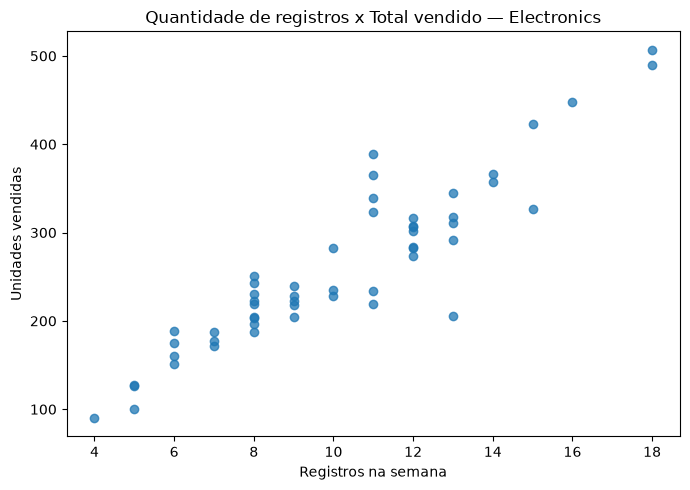

Personal Care: correlação entre total semanal vendido e quantidade de registros = 0.94


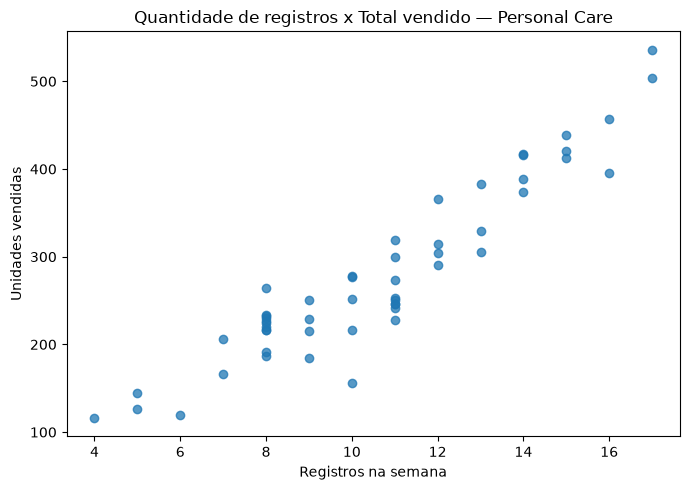

In [3]:
for categoria in categorias:
    temp = weekly_diag[weekly_diag["category"] == categoria]

    corr = temp[["units_sold", "records"]].corr().iloc[0, 1]

    print(
        f"{categoria}: correlação entre total semanal vendido "
        f"e quantidade de registros = {corr:.2f}"
    )

    plt.figure(figsize=(7, 5))
    plt.scatter(
        temp["records"],
        temp["units_sold"],
        alpha=0.75
    )
    plt.title(f"Quantidade de registros x Total vendido — {categoria}")
    plt.xlabel("Registros na semana")
    plt.ylabel("Unidades vendidas")
    plt.tight_layout()
    plt.show()


### Decisão metodológica

Como o total semanal pode ser fortemente afetado pelo número de registros existentes na base, o modelo explicativo será construído no **nível de observação**.

Assim:

- variável-alvo: `units_sold`;
- cada linha continua representando uma observação comercial;
- os fatores comerciais são usados diretamente para prever a quantidade vendida;
- posteriormente, as previsões individuais são agregadas por semana para comparação com os valores observados.

Isso evita atribuir ao preço, desconto ou promoção uma volatilidade que pode ser causada apenas pela quantidade de linhas da amostra.


## 3. Investigação dos fatores comerciais


In [4]:
base["promotion_flag"] = (
    base["promotion_active"]
    .eq("Yes")
    .astype(int)
)

drivers = [
    "units_sold",
    "price",
    "discount_percent",
    "inventory_level",
    "promotion_flag"
]

for categoria in categorias:
    print(f"\n### {categoria}")
    display(
        base.loc[base["category"] == categoria, drivers]
            .corr()
            .round(3)
    )



### Electronics


,units_sold,price,discount_percent,inventory_level,promotion_flag
units_sold,1.00,-0.03,0.20,0.00,0.14
price,-0.03,1.00,-0.04,0.00,-0.04
discount_percent,0.20,-0.04,1.00,-0.01,0.68
inventory_level,0.00,0.00,-0.01,1.00,-0.01
promotion_flag,0.14,-0.04,0.68,-0.01,1.00



### Personal Care


,units_sold,price,discount_percent,inventory_level,promotion_flag
units_sold,1.00,0.04,0.12,0.07,0.07
price,0.04,1.00,0.06,-0.06,0.06
discount_percent,0.12,0.06,1.00,-0.04,0.71
inventory_level,0.07,-0.06,-0.04,1.00,-0.06
promotion_flag,0.07,0.06,0.71,-0.06,1.00


### Promoção × unidades vendidas

Comparamos a média de vendas entre observações com e sem promoção.

A diferença observada é uma associação descritiva e não uma estimativa causal do efeito da promoção.


In [5]:
promotion_summary = (
    base.groupby(["category", "promotion_active"])
        .agg(
            observations=("units_sold", "size"),
            avg_units=("units_sold", "mean"),
            median_units=("units_sold", "median"),
            avg_discount=("discount_percent", "mean"),
            avg_price=("price", "mean")
        )
        .reset_index()
)

display(promotion_summary)


,category,promotion_active,observations,avg_units,median_units,avg_discount,avg_price
0,Electronics,No,258,24.16,22.00,0.00,"1,513.79"
1,Electronics,Yes,278,27.21,27.50,12.93,"1,447.36"
2,Personal Care,No,282,25.60,26.00,0.00,"1,475.75"
3,Personal Care,Yes,279,27.13,27.00,13.87,"1,579.16"


### Desconto × unidades vendidas


In [6]:
discount_summary = (
    base.groupby(["category", "discount_percent"])
        .agg(
            observations=("units_sold", "size"),
            avg_units=("units_sold", "mean"),
            avg_price=("price", "mean")
        )
        .reset_index()
)

display(discount_summary)


,category,discount_percent,observations,avg_units,avg_price
0,Electronics,0,305,24.58,"1,477.97"
1,Electronics,5,49,23.33,"1,620.04"
2,Electronics,10,45,25.67,"1,521.13"
3,Electronics,15,52,27.21,"1,566.92"
4,Electronics,20,43,28.44,"1,289.26"
5,Electronics,30,42,32.52,"1,366.48"
6,Personal Care,0,322,25.55,"1,488.84"
7,Personal Care,5,44,25.91,"1,524.23"
8,Personal Care,10,52,25.54,"1,480.48"
9,Personal Care,15,46,27.24,"1,703.37"


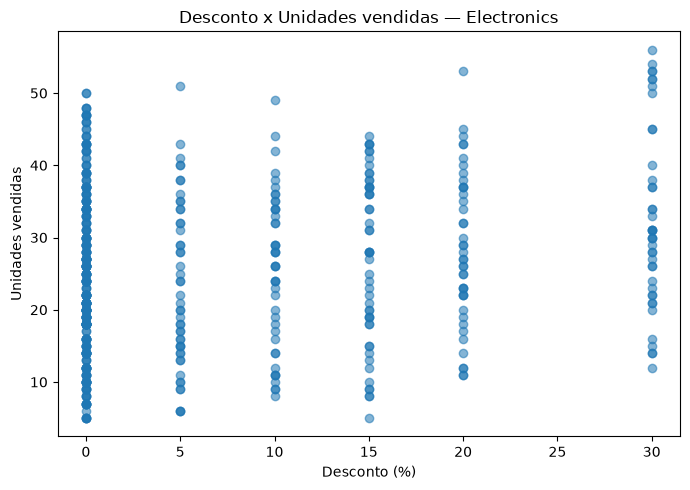

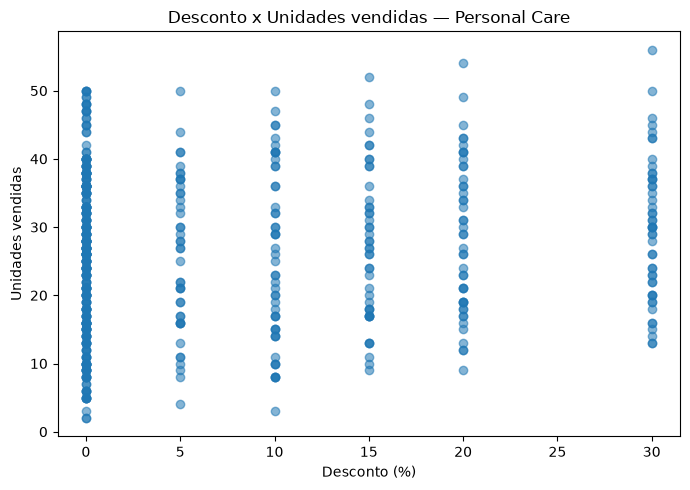

In [7]:
for categoria in categorias:
    temp = base[base["category"] == categoria]

    plt.figure(figsize=(7, 5))
    plt.scatter(
        temp["discount_percent"],
        temp["units_sold"],
        alpha=0.55
    )
    plt.title(f"Desconto x Unidades vendidas — {categoria}")
    plt.xlabel("Desconto (%)")
    plt.ylabel("Unidades vendidas")
    plt.tight_layout()
    plt.show()


### Preço × unidades vendidas


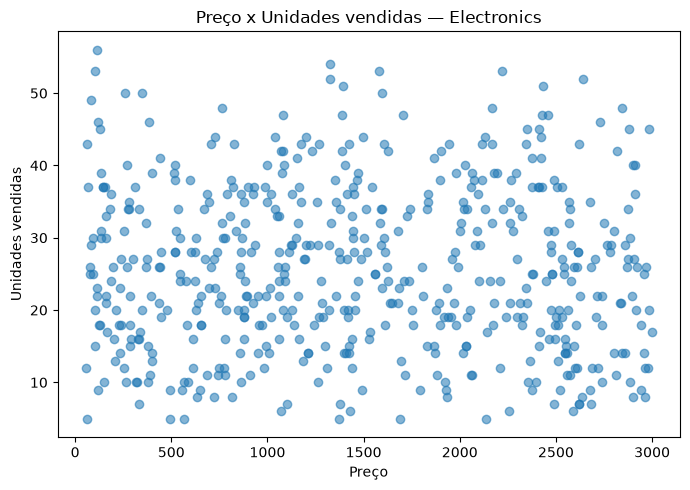

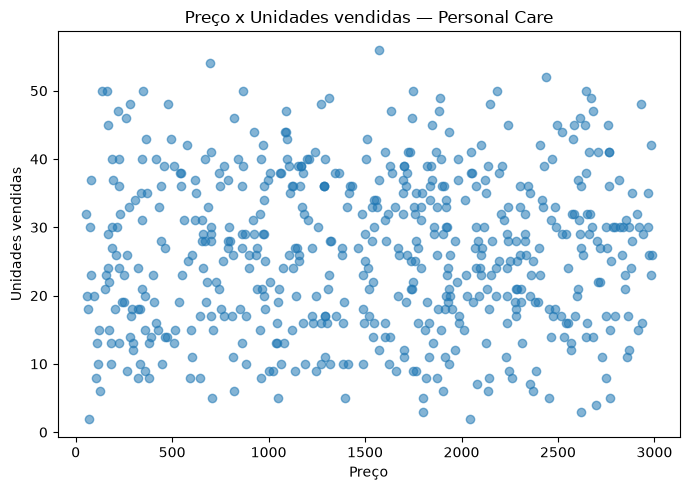

In [8]:
for categoria in categorias:
    temp = base[base["category"] == categoria]

    plt.figure(figsize=(7, 5))
    plt.scatter(
        temp["price"],
        temp["units_sold"],
        alpha=0.55
    )
    plt.title(f"Preço x Unidades vendidas — {categoria}")
    plt.xlabel("Preço")
    plt.ylabel("Unidades vendidas")
    plt.tight_layout()
    plt.show()


### Estoque × unidades vendidas

O estoque disponível pode limitar a quantidade vendida. Ainda assim, uma correlação simples não é suficiente para concluir que estoque maior gera vendas maiores.


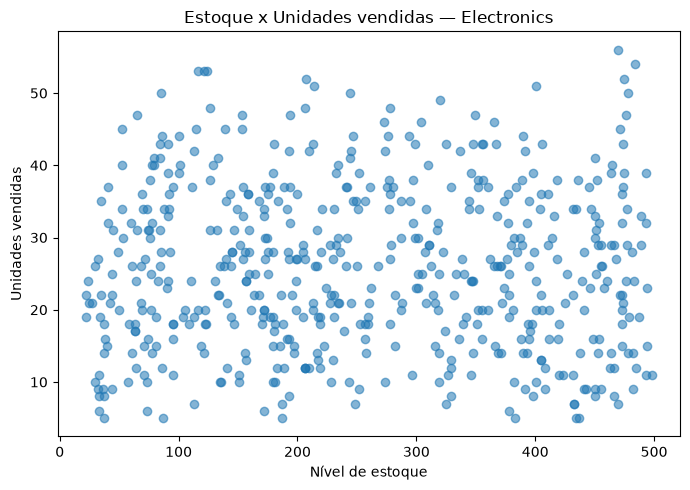

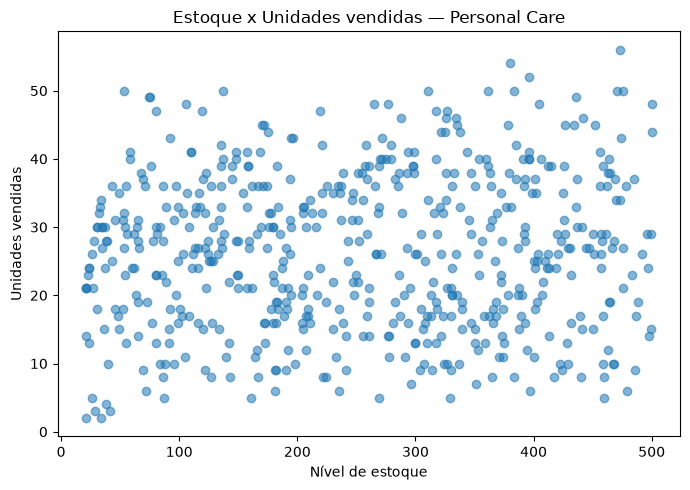

In [9]:
for categoria in categorias:
    temp = base[base["category"] == categoria]

    plt.figure(figsize=(7, 5))
    plt.scatter(
        temp["inventory_level"],
        temp["units_sold"],
        alpha=0.55
    )
    plt.title(f"Estoque x Unidades vendidas — {categoria}")
    plt.xlabel("Nível de estoque")
    plt.ylabel("Unidades vendidas")
    plt.tight_layout()
    plt.show()


## 4. Picos e vales semanais

Agora observamos as semanas de maior e menor volume e os respectivos indicadores comerciais.

O objetivo é verificar se os extremos apresentam padrões semelhantes de promoção, desconto, preço ou estoque.


In [10]:
for categoria in categorias:

    temp = (
        weekly_diag[weekly_diag["category"] == categoria]
        .sort_values("units_sold", ascending=False)
    )

    print(f"\n{categoria} — 5 maiores semanas")
    display(temp.head(5))

    print(f"{categoria} — 5 menores semanas")
    display(temp.tail(5))



Electronics — 5 maiores semanas


,category,date,units_sold,records,avg_units_per_record,avg_price,avg_discount,avg_inventory,promotion_rate
49,Electronics,2024-12-15,507,18,28.17,"1,289.22",8.61,229.72,50.00
20,Electronics,2024-05-26,490,18,27.22,"1,168.17",4.72,314.61,44.44
44,Electronics,2024-11-10,448,16,28.00,"1,721.88",9.06,209.38,62.50
38,Electronics,2024-09-29,423,15,28.20,"1,547.87",7.67,233.33,53.33
10,Electronics,2024-03-17,389,11,35.36,"1,607.27",3.18,288.27,45.45


Electronics — 5 menores semanas


,category,date,units_sold,records,avg_units_per_record,avg_price,avg_discount,avg_inventory,promotion_rate
12,Electronics,2024-03-31,151,6,25.17,"1,640.00",10.00,143.67,50.00
48,Electronics,2024-12-08,128,5,25.60,"1,152.80",4.00,309.40,20.00
22,Electronics,2024-06-09,126,5,25.20,"1,212.80",0.00,193.00,20.00
30,Electronics,2024-08-04,100,5,20.00,"1,620.40",16.00,143.60,100.00
52,Electronics,2025-01-05,90,4,22.50,"1,825.25",15.00,284.00,75.00



Personal Care — 5 maiores semanas


,category,date,units_sold,records,avg_units_per_record,avg_price,avg_discount,avg_inventory,promotion_rate
68,Personal Care,2024-04-21,536,17,31.53,"1,520.82",8.24,211.00,64.71
89,Personal Care,2024-09-15,504,17,29.65,"1,675.88",11.18,287.24,64.71
99,Personal Care,2024-11-24,457,16,28.56,"1,454.56",4.69,284.19,43.75
54,Personal Care,2024-01-14,439,15,29.27,"1,763.47",8.00,229.00,80.00
93,Personal Care,2024-10-13,420,15,28.00,"1,887.67",6.67,302.00,33.33


Personal Care — 5 menores semanas


,category,date,units_sold,records,avg_units_per_record,avg_price,avg_discount,avg_inventory,promotion_rate
53,Personal Care,2024-01-07,156,10,15.60,"1,429.70",6.50,224.80,60.00
63,Personal Care,2024-03-17,145,5,29.00,"2,237.00",9.00,101.40,40.00
94,Personal Care,2024-10-20,126,5,25.20,"1,562.80",12.00,322.00,60.00
80,Personal Care,2024-07-14,120,6,20.00,"1,390.67",0.83,264.33,16.67
105,Personal Care,2025-01-05,116,4,29.00,596.00,2.50,144.50,50.00


## 5. Preparação das features para previsão

O modelo utilizará apenas informações que poderiam ser conhecidas ou planejadas comercialmente:

### Comerciais
- `price`
- `discount_percent`
- `inventory_level`
- `promotion_active`

### Contexto
- `category`
- `store_id`
- dia da semana
- mês
- fim de semana

`product_id` não será utilizado nesta fase porque existem muitos produtos com poucas observações, o que aumentaria muito a dimensionalidade e o risco de overfitting.


In [11]:
model_data = base.copy()

model_data["month_num"] = model_data["date"].dt.month
model_data["day_name"] = model_data["date"].dt.day_name()
model_data["is_weekend_model"] = (
    model_data["date"].dt.dayofweek >= 5
).astype(int)

# Representação cíclica do mês
model_data["month_sin"] = np.sin(
    2 * np.pi * model_data["month_num"] / 12
)
model_data["month_cos"] = np.cos(
    2 * np.pi * model_data["month_num"] / 12
)

features = [
    "price",
    "discount_percent",
    "inventory_level",
    "promotion_active",
    "category",
    "store_id",
    "day_name",
    "is_weekend_model",
    "month_sin",
    "month_cos"
]

target = "units_sold"

X = model_data[features].copy()
y = model_data[target].copy()


## 6. Separação temporal treino/teste

Não utilizaremos divisão aleatória.

O conjunto de teste será formado pelas observações das últimas 8 semanas do histórico, preservando a ordem temporal e simulando uma previsão real de período futuro.


In [12]:
cutoff_date = model_data["date"].max() - pd.Timedelta(weeks=8)

train_mask = model_data["date"] <= cutoff_date
test_mask = model_data["date"] > cutoff_date

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

meta_test = model_data.loc[
    test_mask,
    ["date", "category", "store_id"]
].copy()

print(f"Data de corte: {cutoff_date.date()}")
print(f"Treino: {len(X_train):,} observações")
print(f"Teste: {len(X_test):,} observações")


Data de corte: 2024-11-05
Treino: 907 observações
Teste: 190 observações


## 7. Modelos comerciais

Serão comparados dois modelos:

### Ridge Regression
Modelo linear regularizado, útil como referência interpretável.

### Random Forest
Modelo não linear capaz de capturar interações entre desconto, promoção, preço, estoque, loja e calendário.

O objetivo não é escolher o modelo mais complexo, mas verificar se os fatores comerciais oferecem capacidade preditiva relevante.


In [13]:
numeric_features = [
    "price",
    "discount_percent",
    "inventory_level",
    "is_weekend_model",
    "month_sin",
    "month_cos"
]

categorical_features = [
    "promotion_active",
    "category",
    "store_id",
    "day_name"
]

preprocessor_linear = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

ridge_model = Pipeline([
    ("preprocessor", preprocessor_linear),
    ("model", Ridge(alpha=1.0))
])

rf_model = Pipeline([
    ("preprocessor", preprocessor_tree),
    (
        "model",
        RandomForestRegressor(
            n_estimators=400,
            max_depth=8,
            min_samples_leaf=4,
            random_state=42,
            n_jobs=-1
        )
    )
])


In [14]:
ridge_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

pred_ridge = ridge_model.predict(X_test)
pred_rf = rf_model.predict(X_test)


## 8. Métricas

Além do MAE, RMSE, MAPE e Bias, as métricas serão calculadas também por categoria.


In [15]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mask = y_true != 0

    if mask.sum() == 0:
        return np.nan

    return (
        np.mean(
            np.abs(
                (y_true[mask] - y_pred[mask])
                / y_true[mask]
            )
        )
        * 100
    )


def bias(y_true, y_pred):
    return np.mean(
        np.asarray(y_pred)
        - np.asarray(y_true)
    )


def metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(
            mean_squared_error(y_true, y_pred)
        ),
        "MAPE": mape(y_true, y_pred),
        "Bias": bias(y_true, y_pred)
    }


In [16]:
overall_results = pd.DataFrame([
    {
        "Model": "Ridge",
        **metrics(y_test, pred_ridge)
    },
    {
        "Model": "Random Forest",
        **metrics(y_test, pred_rf)
    }
])

display(overall_results)


,Model,MAE,RMSE,MAPE,Bias
0,Ridge,10.07,12.15,58.33,-0.13
1,Random Forest,9.78,11.68,55.17,-0.70


In [17]:
predictions = meta_test.copy()
predictions["actual"] = y_test.values
predictions["Ridge"] = pred_ridge
predictions["Random Forest"] = pred_rf

category_results = []

for categoria in categorias:

    temp = predictions[
        predictions["category"] == categoria
    ]

    for modelo in ["Ridge", "Random Forest"]:

        category_results.append({
            "Category": categoria,
            "Model": modelo,
            **metrics(
                temp["actual"],
                temp[modelo]
            )
        })

category_results = pd.DataFrame(category_results)

display(
    category_results
    .sort_values(["Category", "MAPE"])
)


,Category,Model,MAE,RMSE,MAPE,Bias
1,Electronics,Random Forest,9.15,11.11,53.36,0.29
0,Electronics,Ridge,9.50,11.57,56.16,0.40
3,Personal Care,Random Forest,10.32,12.16,56.73,-1.56
2,Personal Care,Ridge,10.56,12.63,60.19,-0.58


## 9. Actual vs Predicted — agregado por semana

As previsões são feitas em nível de observação e depois agregadas semanalmente.

Esse gráfico permite comparar a forma da demanda observada com a demanda prevista sem utilizar diretamente o número de registros como variável explicativa.


In [18]:
weekly_predictions = (
    predictions
    .groupby(["date", "category"], as_index=False)
    .agg(
        actual=("actual", "sum"),
        Ridge=("Ridge", "sum"),
        Random_Forest=("Random Forest", "sum")
    )
)

# A agregação acima ainda está por data.
# Reagregamos para semana.
weekly_predictions = (
    weekly_predictions
    .set_index("date")
    .groupby("category")
    .resample("W-SUN")
    .agg(
        actual=("actual", "sum"),
        Ridge=("Ridge", "sum"),
        Random_Forest=("Random_Forest", "sum")
    )
    .reset_index()
)

display(weekly_predictions.head())


,category,date,actual,Ridge,Random_Forest
0,Electronics,2024-11-10,420,424.52,414.75
1,Electronics,2024-11-17,273,303.22,309.84
2,Electronics,2024-11-24,251,198.80,216.54
3,Electronics,2024-12-01,188,219.56,212.62
4,Electronics,2024-12-08,128,119.96,125.61


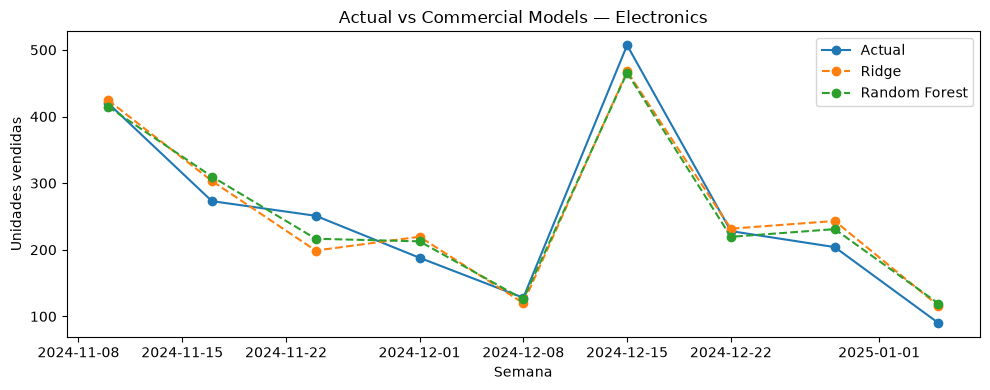

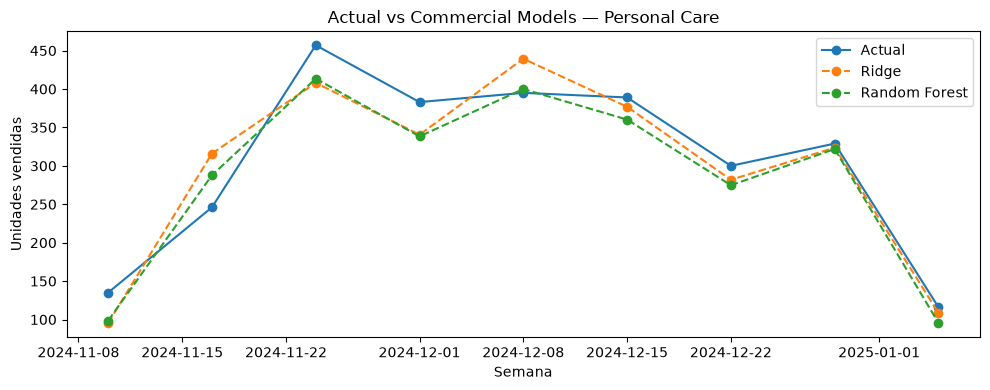

In [19]:
for categoria in categorias:

    temp = weekly_predictions[
        weekly_predictions["category"] == categoria
    ]

    plt.figure(figsize=(10, 4))

    plt.plot(
        temp["date"],
        temp["actual"],
        marker="o",
        label="Actual"
    )

    plt.plot(
        temp["date"],
        temp["Ridge"],
        marker="o",
        linestyle="--",
        label="Ridge"
    )

    plt.plot(
        temp["date"],
        temp["Random_Forest"],
        marker="o",
        linestyle="--",
        label="Random Forest"
    )

    plt.title(
        f"Actual vs Commercial Models — {categoria}"
    )
    plt.xlabel("Semana")
    plt.ylabel("Unidades vendidas")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 10. Importância das variáveis — Random Forest

Usamos **Permutation Importance** diretamente sobre o conjunto de teste.

A medida responde:

> Quanto o desempenho do modelo piora quando embaralhamos uma determinada variável?

Isso ajuda a identificar quais informações tiveram maior utilidade preditiva no período de teste.

A importância continua sendo **preditiva**, não causal.


In [20]:
perm = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

importance = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance": perm.importances_mean
    })
    .sort_values("importance", ascending=True)
)

display(
    importance.sort_values(
        "importance",
        ascending=False
    )
)


,feature,importance
1,discount_percent,0.14
4,category,0.02
7,is_weekend_model,0.02
3,promotion_active,0.01
8,month_sin,0.01
9,month_cos,-0.00
0,price,-0.02
5,store_id,-0.03
2,inventory_level,-0.10
6,day_name,-0.13


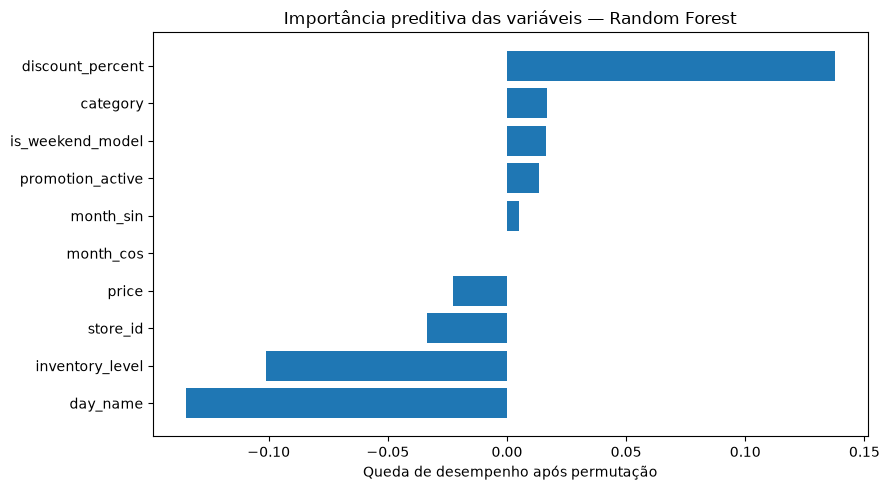

In [21]:
plt.figure(figsize=(9, 5))

bars = plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.title(
    "Importância preditiva das variáveis — Random Forest"
)
plt.xlabel("Queda de desempenho após permutação")
plt.ylabel("")
plt.tight_layout()
plt.show()


## 11. Investigação específica por categoria

Além da importância global, verificamos novamente os principais indicadores descritivos separadamente para Electronics e Personal Care.

Isso é importante porque a relação entre desconto e demanda pode ser diferente entre categorias.


In [22]:
for categoria in categorias:

    temp = base[
        base["category"] == categoria
    ]

    print(f"\n{categoria}")

    resumo = pd.DataFrame({
        "Métrica": [
            "Unidades médias",
            "Preço médio",
            "Desconto médio",
            "% observações em promoção",
            "Estoque médio"
        ],
        "Valor": [
            temp["units_sold"].mean(),
            temp["price"].mean(),
            temp["discount_percent"].mean(),
            temp["promotion_flag"].mean() * 100,
            temp["inventory_level"].mean()
        ]
    })

    display(resumo)



Electronics


,Métrica,Valor
0,Unidades médias,25.74
1,Preço médio,"1,479.33"
2,Desconto médio,6.71
3,% observações em promoção,51.87
4,Estoque médio,256.63



Personal Care


,Métrica,Valor
0,Unidades médias,26.36
1,Preço médio,"1,527.18"
2,Desconto médio,6.90
3,% observações em promoção,49.73
4,Estoque médio,252.44


# 12. Forecast condicionado a cenários comerciais

Há uma diferença importante entre um forecast univariado e este modelo:

### Holt-Winters
Pode projetar o futuro apenas a partir do comportamento passado.

### Modelo com fatores comerciais
Para prever o futuro, precisamos informar quais serão as condições comerciais futuras:

- preço;
- desconto;
- promoção;
- estoque;
- loja;
- calendário.

Por isso, esta etapa gera **previsões condicionais**, e não uma única previsão inevitável.

A seguir criamos uma estrutura de cenário que pode ser modificada manualmente.


In [23]:
# Escolhemos o modelo comercial com menor MAPE geral
best_model_name = (
    overall_results
    .sort_values("MAPE")
    .iloc[0]["Model"]
)

best_model = (
    ridge_model
    if best_model_name == "Ridge"
    else rf_model
)

print("Modelo selecionado:", best_model_name)


Modelo selecionado: Random Forest


## 13. Correção do cenário futuro: preservar a densidade histórica de observações

Na versão anterior, o cenário futuro criou uma linha para **cada loja × cada dia**.  
Isso produziu muito mais observações do que existem historicamente e, consequentemente, inflou o total previsto de unidades.

A correção desta etapa segue uma regra simples:

> **Cada semana futura deve possuir uma quantidade de observações semelhante à quantidade normalmente observada no histórico.**

Para isso:

1. calculamos o número de registros por semana e categoria;
2. usamos a **mediana das últimas 8 semanas** como referência;
3. criamos somente essa quantidade de observações em cada semana futura;
4. preservamos a distribuição recente de lojas e dias da semana por amostragem;
5. alteramos apenas as premissas comerciais do cenário.

Assim, o volume previsto passa a ser comparável com a escala histórica.


In [24]:
FORECAST_WEEKS = 8
RECENT_WEEKS = 8
RANDOM_STATE = 42

recent_cutoff = (
    base["date"].max()
    - pd.Timedelta(weeks=RECENT_WEEKS)
)

recent = (
    base[base["date"] > recent_cutoff]
    .copy()
)

# Quantidade histórica de observações por semana e categoria
recent_weekly_records = (
    recent.set_index("date")
          .groupby("category")
          .resample("W-SUN")
          .size()
          .rename("records")
          .reset_index()
)

records_reference = (
    recent_weekly_records
    .groupby("category")["records"]
    .agg(
        median_records="median",
        mean_records="mean",
        min_records="min",
        max_records="max"
    )
)

display(records_reference)


,median_records,mean_records,min_records,max_records
category,,,,
Electronics,9.00,9.78,4,18
Personal Care,13.00,11.33,4,16


### Interpretação

A mediana é utilizada porque é menos sensível a semanas excepcionalmente cheias ou vazias.

Essa quantidade não representa necessariamente o número real de transações de uma rede varejista.  
Ela representa a **densidade observacional da base disponível**, que precisa ser preservada para que a soma das previsões permaneça comparável ao histórico.


In [25]:
# Referências comerciais recentes por categoria
commercial_reference = (
    recent.groupby("category")
          .agg(
              median_price=("price", "median"),
              median_discount=("discount_percent", "median"),
              median_inventory=("inventory_level", "median"),
              promotion_rate=(
                  "promotion_active",
                  lambda x: (x == "Yes").mean()
              )
          )
)

display(commercial_reference)


,median_price,median_discount,median_inventory,promotion_rate
category,,,,
Electronics,"1,284.00",0.00,237.50,0.52
Personal Care,"1,670.50",0.00,243.50,0.42


## 14. Construção de cenários comerciais

Criaremos três cenários:

- **Base**: mantém preço, desconto, estoque e promoção próximos ao padrão recente;
- **Desconto +5 p.p.**: aumenta o desconto em 5 pontos percentuais;
- **Desconto +10 p.p.**: aumenta o desconto em 10 pontos percentuais.

Neste momento mantemos as demais premissas constantes para isolar o comportamento estimado associado ao desconto.

> Os cenários são simulações condicionais. Eles não representam causalidade nem garantem que a demanda responderá dessa forma no mundo real.


In [26]:
SCENARIOS = {
    "Base": 0,
    "Discount +5pp": 5,
    "Discount +10pp": 10
}

last_date = base["date"].max()

# Domingos que encerram as 8 semanas futuras
first_future_sunday = (
    last_date
    + pd.offsets.Week(weekday=6)
)

future_week_ends = pd.date_range(
    start=first_future_sunday,
    periods=FORECAST_WEEKS,
    freq="W-SUN"
)

future_week_ends


DatetimeIndex(['2025-01-05', '2025-01-12', '2025-01-19', '2025-01-26',
               '2025-02-02', '2025-02-09', '2025-02-16', '2025-02-23'],
              dtype='datetime64[us]', freq='W-SUN')

In [27]:
def build_future_scenario(
    recent_data,
    records_reference,
    commercial_reference,
    scenario_name,
    discount_increment,
    random_state=42
):
    rng = np.random.default_rng(random_state)
    rows = []

    for categoria in categorias:

        cat_recent = (
            recent_data[
                recent_data["category"] == categoria
            ]
            .copy()
        )

        # Número de observações a preservar por semana
        n_records = int(
            round(
                records_reference.loc[
                    categoria,
                    "median_records"
                ]
            )
        )

        ref = commercial_reference.loc[categoria]

        for week_number, week_end in enumerate(
            future_week_ends,
            start=1
        ):

            # Amostragem de observações recentes para preservar
            # aproximadamente o mix de lojas e dias da semana.
            sampled = cat_recent.sample(
                n=n_records,
                replace=True,
                random_state=(
                    random_state
                    + week_number
                    + (0 if categoria == categorias[0] else 1000)
                )
            ).copy()

            # Mantemos o dia da semana da observação amostrada,
            # mas deslocamos a data para a semana futura correspondente.
            sampled_day_num = sampled["date"].dt.dayofweek.to_numpy()

            week_start = (
                week_end
                - pd.Timedelta(days=6)
            )

            future_dates = [
                week_start
                + pd.Timedelta(days=int(day_num))
                for day_num in sampled_day_num
            ]

            # Promoção conforme proporção recente da categoria
            promo_flags = (
                rng.random(n_records)
                < ref["promotion_rate"]
            )

            scenario_discount = min(
                100,
                ref["median_discount"]
                + discount_increment
            )

            for i in range(n_records):
                rows.append({
                    "scenario": scenario_name,
                    "forecast_week": week_end,
                    "date": future_dates[i],
                    "category": categoria,
                    "store_id": sampled.iloc[i]["store_id"],
                    "price": ref["median_price"],
                    "discount_percent": scenario_discount,
                    "inventory_level": ref["median_inventory"],
                    "promotion_active": (
                        "Yes"
                        if promo_flags[i]
                        else "No"
                    )
                })

    future = pd.DataFrame(rows)

    future["month_num"] = future["date"].dt.month
    future["day_name"] = future["date"].dt.day_name()

    future["is_weekend_model"] = (
        future["date"].dt.dayofweek >= 5
    ).astype(int)

    future["month_sin"] = np.sin(
        2 * np.pi
        * future["month_num"]
        / 12
    )

    future["month_cos"] = np.cos(
        2 * np.pi
        * future["month_num"]
        / 12
    )

    return future


In [28]:
scenario_frames = []

for scenario_name, discount_increment in SCENARIOS.items():

    temp = build_future_scenario(
        recent_data=recent,
        records_reference=records_reference,
        commercial_reference=commercial_reference,
        scenario_name=scenario_name,
        discount_increment=discount_increment,
        random_state=RANDOM_STATE
    )

    scenario_frames.append(temp)

future_scenarios = pd.concat(
    scenario_frames,
    ignore_index=True
)

print("Total de observações futuras:", len(future_scenarios))

display(
    future_scenarios.groupby(
        ["scenario", "category", "forecast_week"]
    ).size().rename("records").reset_index().head(20)
)


Total de observações futuras: 528


,scenario,category,forecast_week,records
0,Base,Electronics,2025-01-05,9
1,Base,Electronics,2025-01-12,9
2,Base,Electronics,2025-01-19,9
3,Base,Electronics,2025-01-26,9
4,Base,Electronics,2025-02-02,9
5,Base,Electronics,2025-02-09,9
6,Base,Electronics,2025-02-16,9
7,Base,Electronics,2025-02-23,9
8,Base,Personal Care,2025-01-05,13
9,Base,Personal Care,2025-01-12,13


## 15. Previsão condicionada aos cenários

Aplicamos o modelo comercial vencedor às observações futuras simuladas.

Depois, somamos as previsões por semana e categoria.

Como o número de observações semanais foi preservado, os totais agora ficam na mesma ordem de grandeza do histórico.


In [29]:
X_future = future_scenarios[features]

future_scenarios["forecast_units"] = np.maximum(
    best_model.predict(X_future),
    0
)

future_weekly = (
    future_scenarios
    .groupby(
        ["scenario", "category", "forecast_week"],
        as_index=False
    )
    .agg(
        forecast_units=("forecast_units", "sum"),
        records=("forecast_units", "size"),
        avg_forecast_per_record=("forecast_units", "mean"),
        assumed_price=("price", "mean"),
        assumed_discount=("discount_percent", "mean"),
        assumed_inventory=("inventory_level", "mean"),
        promotion_rate=(
            "promotion_active",
            lambda x: (x == "Yes").mean() * 100
        )
    )
)

display(future_weekly.head(20))


,scenario,category,forecast_week,forecast_units,records,avg_forecast_per_record,assumed_price,assumed_discount,assumed_inventory,promotion_rate
0,Base,Electronics,2025-01-05,228.68,9,25.41,"1,284.00",0.00,237.50,33.33
1,Base,Electronics,2025-01-12,222.66,9,24.74,"1,284.00",0.00,237.50,55.56
2,Base,Electronics,2025-01-19,223.65,9,24.85,"1,284.00",0.00,237.50,33.33
3,Base,Electronics,2025-01-26,222.88,9,24.76,"1,284.00",0.00,237.50,66.67
4,Base,Electronics,2025-02-02,227.35,9,25.26,"1,284.00",0.00,237.50,55.56
5,Base,Electronics,2025-02-09,224.06,9,24.90,"1,284.00",0.00,237.50,55.56
6,Base,Electronics,2025-02-16,225.97,9,25.11,"1,284.00",0.00,237.50,44.44
7,Base,Electronics,2025-02-23,231.72,9,25.75,"1,284.00",0.00,237.50,55.56
8,Base,Personal Care,2025-01-05,332.64,13,25.59,"1,670.50",0.00,243.50,53.85
9,Base,Personal Care,2025-01-12,335.44,13,25.80,"1,670.50",0.00,243.50,53.85


## 16. Validação de escala

Antes de interpretar os cenários, comparamos a escala prevista com o histórico recente.

O objetivo não é exigir valores idênticos, mas confirmar que a previsão futura não foi inflada simplesmente por uma quantidade artificialmente maior de registros.


In [30]:
historical_scale = (
    weekly_diag[
        weekly_diag["category"].isin(categorias)
    ]
    .groupby("category")
    .agg(
        historical_weekly_median=("units_sold", "median"),
        historical_weekly_mean=("units_sold", "mean"),
        historical_weekly_min=("units_sold", "min"),
        historical_weekly_max=("units_sold", "max")
    )
)

base_scale = (
    future_weekly[
        future_weekly["scenario"] == "Base"
    ]
    .groupby("category")
    .agg(
        forecast_weekly_median=("forecast_units", "median"),
        forecast_weekly_mean=("forecast_units", "mean"),
        forecast_weekly_min=("forecast_units", "min"),
        forecast_weekly_max=("forecast_units", "max")
    )
)

scale_check = historical_scale.join(base_scale)

display(scale_check)


,historical_weekly_median,historical_weekly_mean,historical_weekly_min,historical_weekly_max,forecast_weekly_median,forecast_weekly_mean,forecast_weekly_min,forecast_weekly_max
category,,,,,,,,
Electronics,235.00,260.36,90,507,225.01,225.87,222.66,231.72
Personal Care,251.00,279.00,116,536,333.80,333.81,331.25,336.20


## 17. Histórico × cenário-base corrigido


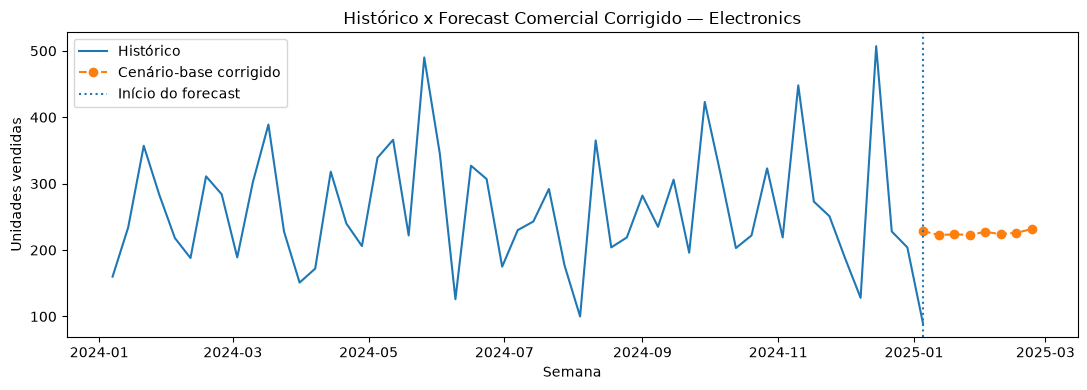

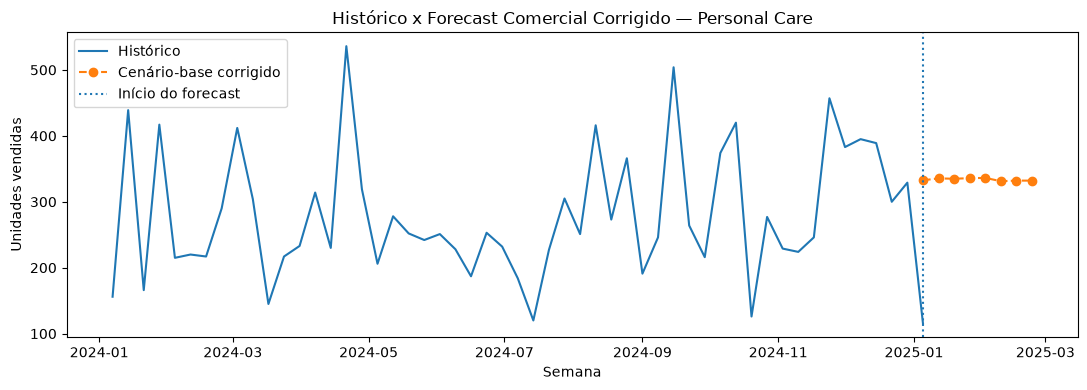

In [31]:
for categoria in categorias:

    hist = weekly_diag[
        weekly_diag["category"] == categoria
    ].copy()

    future = future_weekly[
        (future_weekly["category"] == categoria)
        & (future_weekly["scenario"] == "Base")
    ].copy()

    plt.figure(figsize=(11, 4))

    plt.plot(
        hist["date"],
        hist["units_sold"],
        label="Histórico"
    )

    plt.plot(
        future["forecast_week"],
        future["forecast_units"],
        marker="o",
        linestyle="--",
        label="Cenário-base corrigido"
    )

    plt.axvline(
        hist["date"].max(),
        linestyle=":",
        label="Início do forecast"
    )

    plt.title(
        f"Histórico x Forecast Comercial Corrigido — {categoria}"
    )

    plt.xlabel("Semana")
    plt.ylabel("Unidades vendidas")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 18. Comparação entre cenários de desconto

Agora podemos comparar os três cenários mantendo a mesma quantidade de observações e alterando somente a premissa de desconto.

A diferença entre as linhas representa a resposta estimada pelo modelo sob cada condição comercial.


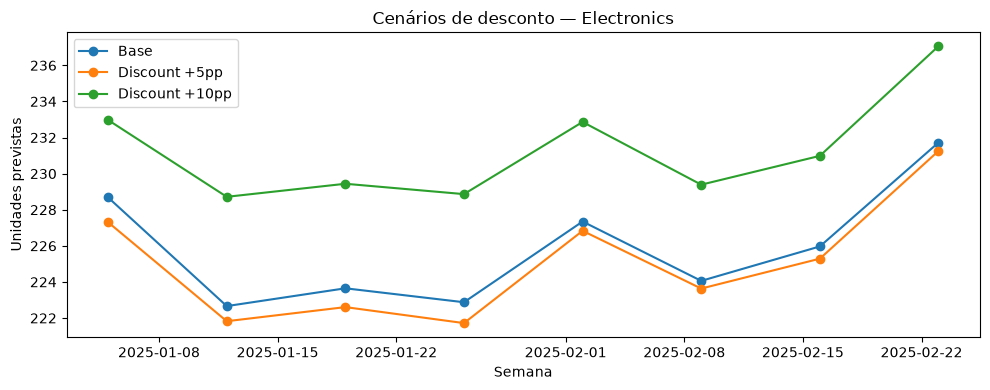

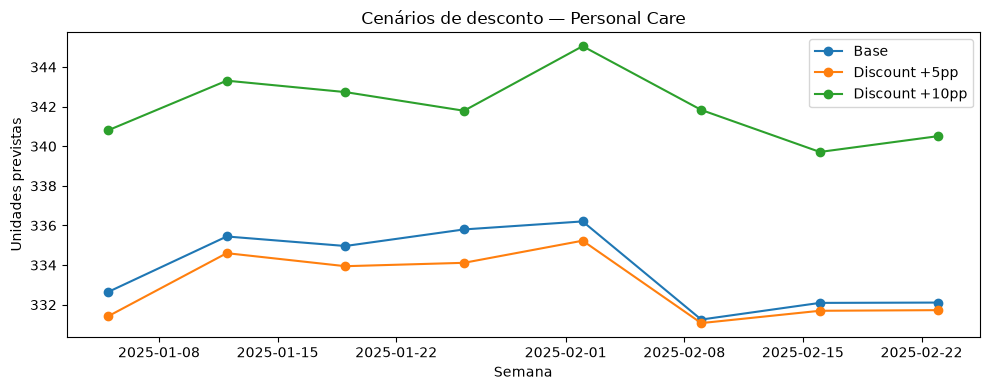

In [32]:
for categoria in categorias:

    temp = future_weekly[
        future_weekly["category"] == categoria
    ].copy()

    plt.figure(figsize=(10, 4))

    for scenario in SCENARIOS.keys():

        scenario_data = temp[
            temp["scenario"] == scenario
        ]

        plt.plot(
            scenario_data["forecast_week"],
            scenario_data["forecast_units"],
            marker="o",
            label=scenario
        )

    plt.title(
        f"Cenários de desconto — {categoria}"
    )

    plt.xlabel("Semana")
    plt.ylabel("Unidades previstas")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 19. Impacto acumulado dos cenários

Para facilitar a futura análise financeira, agregamos as 8 semanas de cada cenário.


In [33]:
scenario_summary = (
    future_weekly
    .groupby(["category", "scenario"], as_index=False)
    .agg(
        forecast_units_8w=("forecast_units", "sum"),
        avg_weekly_units=("forecast_units", "mean"),
        assumed_discount=("assumed_discount", "mean"),
        assumed_price=("assumed_price", "mean")
    )
)

base_values = (
    scenario_summary[
        scenario_summary["scenario"] == "Base"
    ][
        ["category", "forecast_units_8w"]
    ]
    .rename(
        columns={
            "forecast_units_8w": "base_units_8w"
        }
    )
)

scenario_summary = scenario_summary.merge(
    base_values,
    on="category",
    how="left"
)

scenario_summary["unit_change_vs_base"] = (
    scenario_summary["forecast_units_8w"]
    - scenario_summary["base_units_8w"]
)

scenario_summary["unit_change_pct_vs_base"] = (
    scenario_summary["unit_change_vs_base"]
    / scenario_summary["base_units_8w"]
    * 100
)

display(scenario_summary)


,category,scenario,forecast_units_8w,avg_weekly_units,assumed_discount,assumed_price,base_units_8w,unit_change_vs_base,unit_change_pct_vs_base
0,Electronics,Base,"1,806.96",225.87,0.00,"1,284.00","1,806.96",0.00,0.00
1,Electronics,Discount +10pp,"1,850.28",231.29,10.00,"1,284.00","1,806.96",43.33,2.40
2,Electronics,Discount +5pp,"1,800.46",225.06,5.00,"1,284.00","1,806.96",-6.49,-0.36
3,Personal Care,Base,"2,670.50",333.81,0.00,"1,670.50","2,670.50",0.00,0.00
4,Personal Care,Discount +10pp,"2,735.74",341.97,10.00,"1,670.50","2,670.50",65.24,2.44
5,Personal Care,Discount +5pp,"2,663.80",332.97,5.00,"1,670.50","2,670.50",-6.70,-0.25


# 20. Conclusão metodológica desta correção

A versão corrigida resolve o principal problema identificado na projeção anterior:

- o forecast não cria mais todas as combinações possíveis de loja e dia;
- cada semana futura conserva uma quantidade de observações semelhante ao histórico;
- a composição de lojas e dias é amostrada do período recente;
- as alterações de cenário ficam concentradas nas premissas comerciais.

Com isso, a previsão passa a responder uma pergunta mais adequada:

> **Mantendo uma estrutura de observações semelhante à histórica, como a demanda estimada varia sob diferentes condições comerciais?**

Ainda assim, esses resultados devem ser tratados como **simulações preditivas condicionais**, e não como estimativas causais do efeito de desconto.


## 21. Exportação

São exportados:

- resultados gerais dos modelos;
- resultados por categoria;
- importância das variáveis;
- forecast futuro detalhado;
- forecast semanal por cenário;
- resumo acumulado dos cenários.

Esses arquivos serão utilizados na etapa de planejamento financeiro.


In [34]:
overall_results.to_csv(
    "commercial_model_results_overall.csv",
    index=False,
    encoding="utf-8-sig"
)

category_results.to_csv(
    "commercial_model_results_by_category.csv",
    index=False,
    encoding="utf-8-sig"
)

importance.sort_values(
    "importance",
    ascending=False
).to_csv(
    "commercial_driver_importance.csv",
    index=False,
    encoding="utf-8-sig"
)

future_scenarios.to_csv(
    "commercial_future_scenarios_detailed.csv",
    index=False,
    encoding="utf-8-sig"
)

future_weekly.to_csv(
    "commercial_forecast_scenarios_8_weeks.csv",
    index=False,
    encoding="utf-8-sig"
)

scenario_summary.to_csv(
    "commercial_scenario_summary_8_weeks.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Arquivos gerados:")
print("- commercial_model_results_overall.csv")
print("- commercial_model_results_by_category.csv")
print("- commercial_driver_importance.csv")
print("- commercial_future_scenarios_detailed.csv")
print("- commercial_forecast_scenarios_8_weeks.csv")
print("- commercial_scenario_summary_8_weeks.csv")


Arquivos gerados:
- commercial_model_results_overall.csv
- commercial_model_results_by_category.csv
- commercial_driver_importance.csv
- commercial_future_scenarios_detailed.csv
- commercial_forecast_scenarios_8_weeks.csv
- commercial_scenario_summary_8_weeks.csv
